In [1]:
from matplotlib import pyplot as plt
import pandas as pd

FIG_SIZE_X = 10
FIG_SIZE_Y = 5
DPI = 60
FONT_SIZE = 18

INPUT_FILE  = 'gval-IRT.csv'
OUTPUT_FILE = 'gval-IRT.pkl'

%matplotlib inline

In [2]:
# read csv file
df = pd.read_csv(INPUT_FILE)
pd.set_option('display.max_columns', 20)
pd.set_option('display.max_rows', 61)
df

,Time_ps,H^0,H_2^0,H2O2^0,H3O^1,HO_2^0,HO_2^-1,None^0,O^0,O_2^0,O_2^-1,O_3^0,O_3^-1,OH^0,OH^-1,O^-1,e_aq^-1
0,1.00000,0.670581,0.189796,0.050932,4.14878,0.000001,0.000000,0,0,0.000000,0.000000,0,0,5.07565,0.055531,0.000073,4.13513
1,1.25893,0.670581,0.189813,0.052023,4.14878,0.000001,0.000000,0,0,0.000000,0.000000,0,0,5.07565,0.055942,0.000078,4.13513
2,1.58489,0.670493,0.189873,0.053711,4.14860,0.000001,0.000000,0,0,0.000000,0.000000,0,0,5.07333,0.056439,0.000085,4.13487
3,1.99526,0.669795,0.190036,0.057024,4.14775,0.000001,0.000000,0,0,0.000000,0.000000,0,0,5.06385,0.056807,0.000085,4.13343
4,2.51189,0.668974,0.190227,0.060650,4.14699,0.000001,0.000000,0,0,0.000000,0.000000,0,0,5.05457,0.057389,0.000103,4.13206
5,3.16228,0.668157,0.190438,0.064743,4.14603,0.000001,0.000000,0,0,0.000000,0.000000,0,0,5.04401,0.057893,0.000113,4.13052
6,3.98107,0.667027,0.190694,0.069629,4.14496,0.000001,0.000000,0,0,0.000000,0.000000,0,0,5.03176,0.058778,0.000115,4.12860
7,5.01187,0.665799,0.190954,0.075124,4.14358,0.000001,0.000000,0,0,0.000000,0.000000,0,0,5.01732,0.059529,0.000115,4.12643
8,6.30957,0.664146,0.191296,0.081459,4.14208,0.000001,0.000000,0,0,0.000000,0.000000,0,0,5.00029,0.060707,0.000126,4.12358
9,7.94328,0.662401,0.191626,0.088733,4.14021,0.000001,0.000000,0,0,0.000000,0.000000,0,0,4.98150,0.061894,0.000153,4.12054


In [3]:
label = {'H^0'   : 'H',   'H_2^0'  : 'H2',   'H2O2^0' : 'H2O2', 'H3O^1': 'H3Op', 
         'HO_2^0': 'HO2', 'HO_2^-1': 'HO2m', 'O^0'    : 'O',    'O_2^0': 'O2', 
         'O_2^-1': 'O2m', 'O_3^0'  : 'O3',   'O_3^-1' : 'O3m',   'OH^0': 'OH',
         'OH^-1' : 'OHm', 'O^-1'   : 'Om',   'e_aq^-1': 'e_aq'}

In [4]:
def plot(x, y, title):
    plt.figure(figsize = (FIG_SIZE_X, FIG_SIZE_Y), dpi = DPI)
    plt.plot(x, y, label = "Geant4-DNA", linewidth = 3.0)
    plt.grid(True)
    plt.title(title, fontsize = FONT_SIZE)
    plt.xlabel("Time (ps)", fontsize = FONT_SIZE)
    plt.ylabel("G-value", fontsize = FONT_SIZE)
    plt.xscale("log")
    plt.legend(fontsize = FONT_SIZE)
    plt.tick_params(labelsize = FONT_SIZE)
    plt.show()

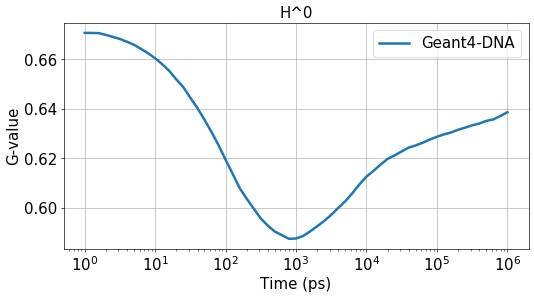

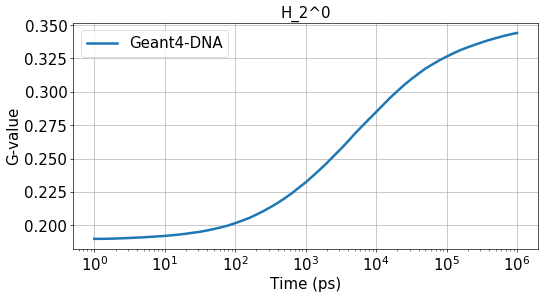

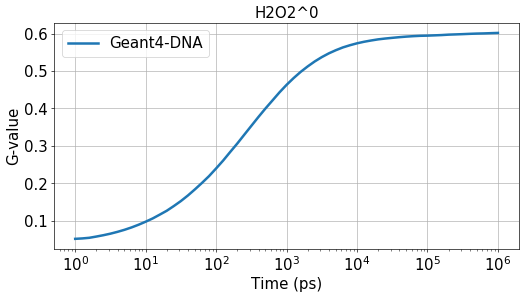

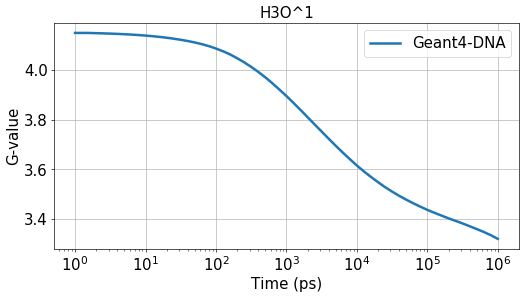

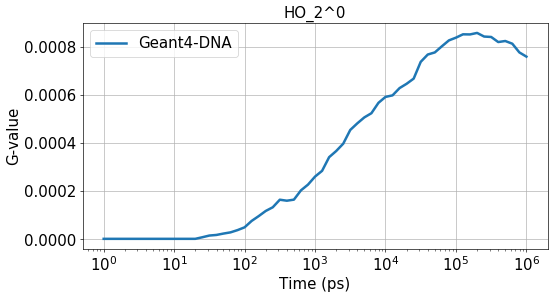

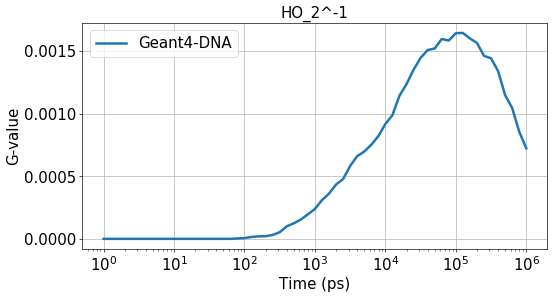

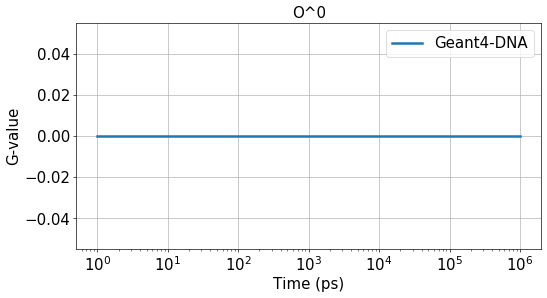

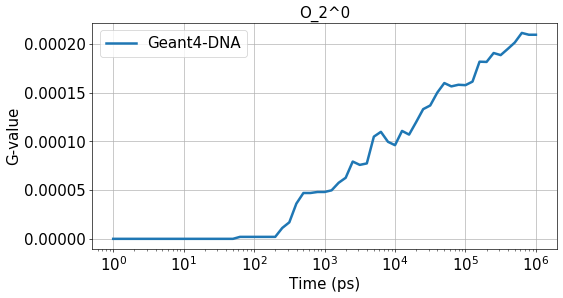

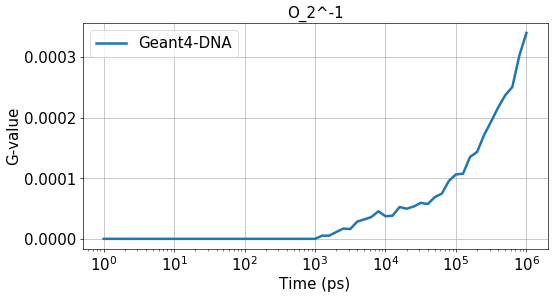

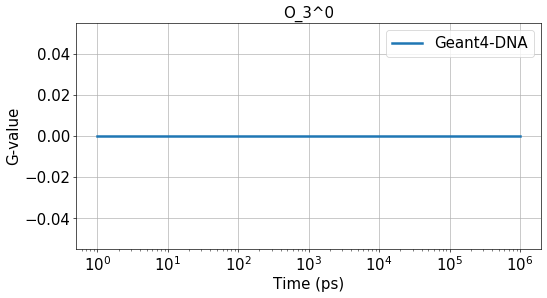

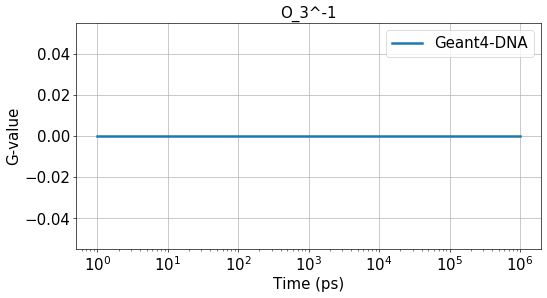

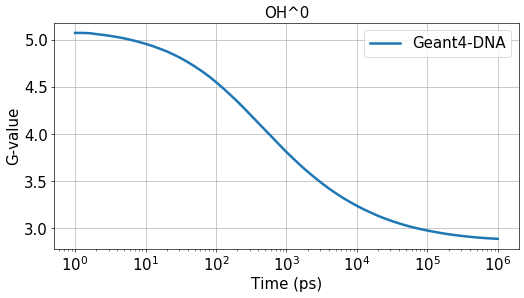

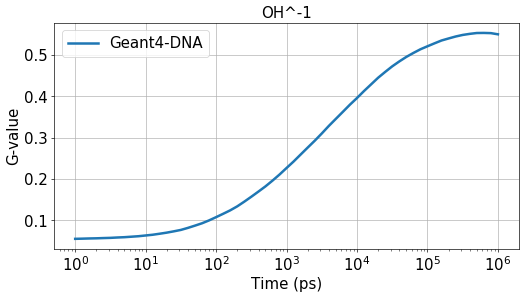

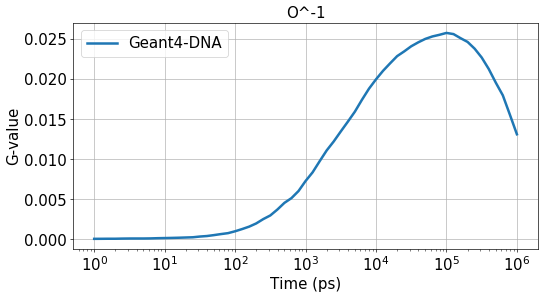

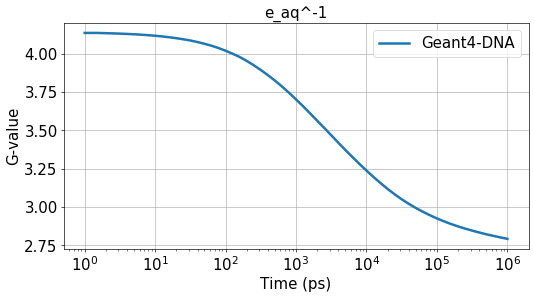

In [5]:
# make G-value plots
output = {"time": df['Time_ps'].values}
for x in df.columns:
    if x == 'Time_ps' or x == "None^0":
      continue
    plot(df['Time_ps'], df[x], x)
    output[label[x]] = df[x].values

# make data frame with Pandas and save as pickle file
pd.DataFrame.from_dict(output).to_pickle(OUTPUT_FILE)